# Visualize Preprocessed DNS Snapshots (Static Plots)

This notebook loads a subsampled `.npz` file and provides tools to visualize the data across different spatial and temporal planes. 

**Key Features:**
- **Consistent Color Scales:** A single, global color palette is calculated and applied to all plots for accurate visual comparison across all components and orientations.
- **Grouped Parameters:** You only need to set the slice/line parameters once for each group of plots.
- **Individual Execution:** You can still run a single cell to regenerate a plot for just one velocity component after changing the shared parameters.

### 1. Setup and Imports

In [1]:
import numpy as np
from pathlib import Path
import logging

# Import all necessary plotting functions from your core module
from mhd_surrogate_core.plotting import (
    plot_xz_slice, 
    plot_xy_slice, 
    plot_yz_slice,
    plot_z_time_evolution,
    plot_x_time_evolution,
    plot_y_time_evolution
)

### 2. User Configuration

**Action Required:** Set your parameters in this cell. You can re-run this cell anytime to apply changes without reloading the data.

In [2]:
# <<< 1. SET DATA FILE PATH >>>
# This is only used when the 'Load Data' cell is run.
data_file_path = Path("/raid/skowronek/preprocessed_dns_output/01-Cold_Runs/01-Re16K_Ha325/T1220_x1151_y5_z127_c3/T1220_x1151_y5_z127_c3.npz")

# <<< 2. DEFINE CHANNEL NAME MAPPING >>>
# Maps data channel names to display names for plots.
channel_map = {
    'vx': 'u',
    'vy': 'v',
    'vz': 'w'
    # You can add other mappings here, e.g., 'bx': 'Bx'
}

# <<< 3. SET GLOBAL PLOT SIZING PARAMETERS >>>
# Controls the overall size of the longest dimension of the dynamic plots.
global_base_size = 20
# Controls the minimum size of the shortest dimension of the dynamic plots.
global_min_size = 0.1

# <<< 4. SET UNIT LABEL FOR COLORBAR >>>
# E.g., "m/s", "T", etc. Set to None or "" for no unit.
global_unit_label = None

# <<< 5. SET GLOBAL COLOR SCALE OVERRIDE (OPTIONAL) >>>
# Set to a number to enforce a specific vmin/vmax, or None to auto-calculate from the data.
global_vmin_override = -5
global_vmax_override = 6

print("Configuration set. You can now run the 'Load Data' cell if you haven't already.")

Configuration set. You can now run the 'Load Data' cell if you haven't already.


### 3. Load Data

**Run this cell only once** at the beginning of your session or after changing the `data_file_path` above.

In [3]:
# --- Data Loading and Initialization ---
timeseries_data = None
coords = {}

if 'data_file_path' not in locals() or not data_file_path.exists():
    logging.error(f"ERROR: Data file not found at {globals().get('data_file_path', 'Not Set')}. Please set the correct path in the configuration cell.")
else:
    with np.load(data_file_path, allow_pickle=True) as data:
        timeseries_data = data['timeseries']
        coords = {
            'labels': list(data['labels']),
            'x': data['x_coords'],
            'y': data['y_coords'],
            'z': data['z_coords'],
        }
        # Assumes data shape is (time, x, y, z, channel)
        max_time_index = timeseries_data.shape[0] - 1
        max_x_index = timeseries_data.shape[1] - 1
        max_y_index = timeseries_data.shape[2] - 1
        max_z_index = timeseries_data.shape[3] - 1
    
    print("Data loaded successfully into memory.")
    print(f"Available channels: {coords['labels']}")
    print(f"Max indices -> Time: {max_time_index}, X: {max_x_index}, Y: {max_y_index}, Z: {max_z_index}")

# Automatically identify velocity components to be plotted based on the channel_map
velocity_components = sorted([c for c in coords.get('labels', []) if c in channel_map])
if not velocity_components:
    logging.warning("Warning: No velocity components matching the channel_map found in the data.")
else:
    print(f"Identified velocity components to plot: {velocity_components}")

Data loaded successfully into memory.
Available channels: ['vx', 'vy', 'vz']
Max indices -> Time: 1219, X: 1150, Y: 4, Z: 126
Identified velocity components to plot: ['vx', 'vy', 'vz']


### 4. Calculate Global Color Scale

Run this cell to determine the color scale that will be applied to **all** subsequent plots.

In [4]:
# --- Calculate the global vmin and vmax across all velocity components ---
global_timeseries_vmin, global_timeseries_vmax = None, None

if global_vmin_override is not None and global_vmax_override is not None:
    global_timeseries_vmin = global_vmin_override
    global_timeseries_vmax = global_vmax_override
    print(f"Using user-defined global color scale: [{global_timeseries_vmin:.3f}, {global_timeseries_vmax:.3f}]")
elif timeseries_data is not None and velocity_components:
    all_vc_data = []
    for vc in velocity_components:
        vc_idx = coords['labels'].index(vc)
        all_vc_data.append(timeseries_data[..., vc_idx])
    
    global_timeseries_vmin = min(d.min() for d in all_vc_data)
    global_timeseries_vmax = max(d.max() for d in all_vc_data)
    print(f"Auto-calculated global color scale for all plots: [{global_timeseries_vmin:.3f}, {global_timeseries_vmax:.3f}]")

Using user-defined global color scale: [-5.000, 6.000]


---

### 5. Spatial Slice Plots (2D)

#### 5.1 X-Z Slices (at constant Y)

In [5]:
# === Parameters for X-Z Slices ===
# <<< MODIFY THESE VALUES >>>
plot_y_index_xz = max_y_index // 2
plot_time_index_xz = max_time_index // 2
# ---
print(f"Using y-index {plot_y_index_xz} and time-index {plot_time_index_xz} for X-Z slice plots.")

Using y-index 2 and time-index 609 for X-Z slice plots.


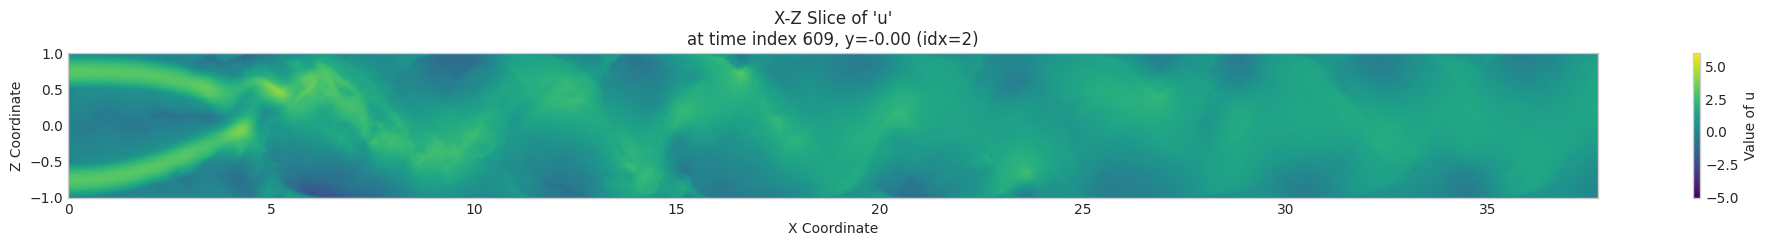

In [6]:
# === Plot X-Z Slice for u (vx) ===
if 'vx' in velocity_components:
    plot_xz_slice(
        data_path=None, # Data is in memory
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vx',
        y_index=plot_y_index_xz,
        time_index=plot_time_index_xz,
        channel_alias=channel_map.get('vx'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

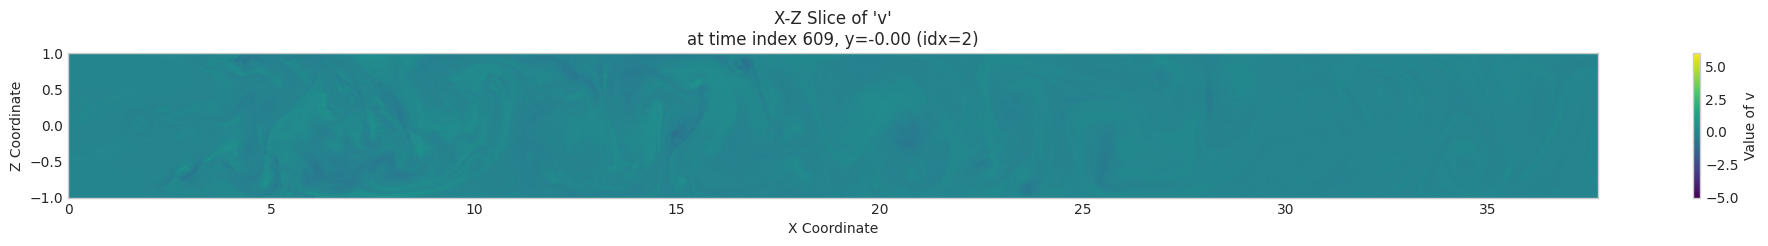

In [7]:
# === Plot X-Z Slice for v (vy) ===
if 'vy' in velocity_components:
    plot_xz_slice(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vy',
        y_index=plot_y_index_xz,
        time_index=plot_time_index_xz,
        channel_alias=channel_map.get('vy'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

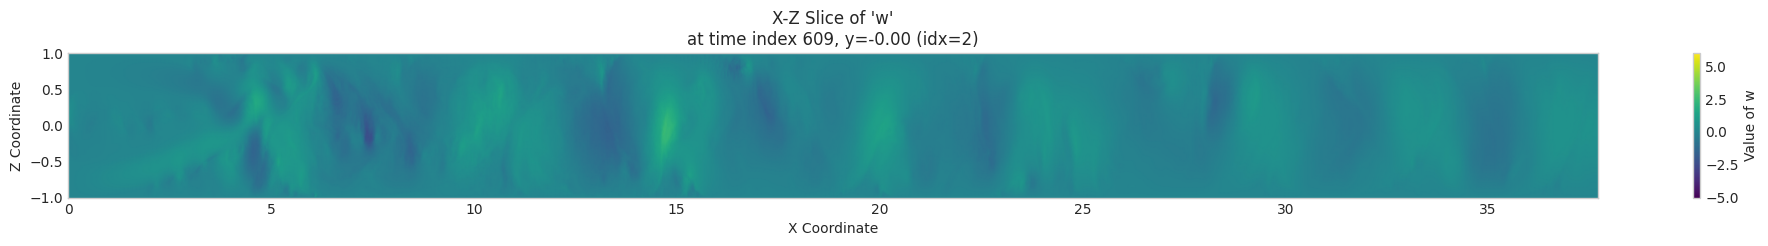

In [8]:
# === Plot X-Z Slice for w (vz) ===
if 'vz' in velocity_components:
    plot_xz_slice(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vz',
        y_index=plot_y_index_xz,
        time_index=plot_time_index_xz,
        channel_alias=channel_map.get('vz'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

#### 5.2 X-Y Slices (at constant Z)

In [9]:
# === Parameters for X-Y Slices ===
# <<< MODIFY THESE VALUES >>>
plot_z_index_xy = max_z_index // 2
plot_time_index_xy = max_time_index // 2
# ---
print(f"Using z-index {plot_z_index_xy} and time-index {plot_time_index_xy} for X-Y slice plots.")

Using z-index 63 and time-index 609 for X-Y slice plots.


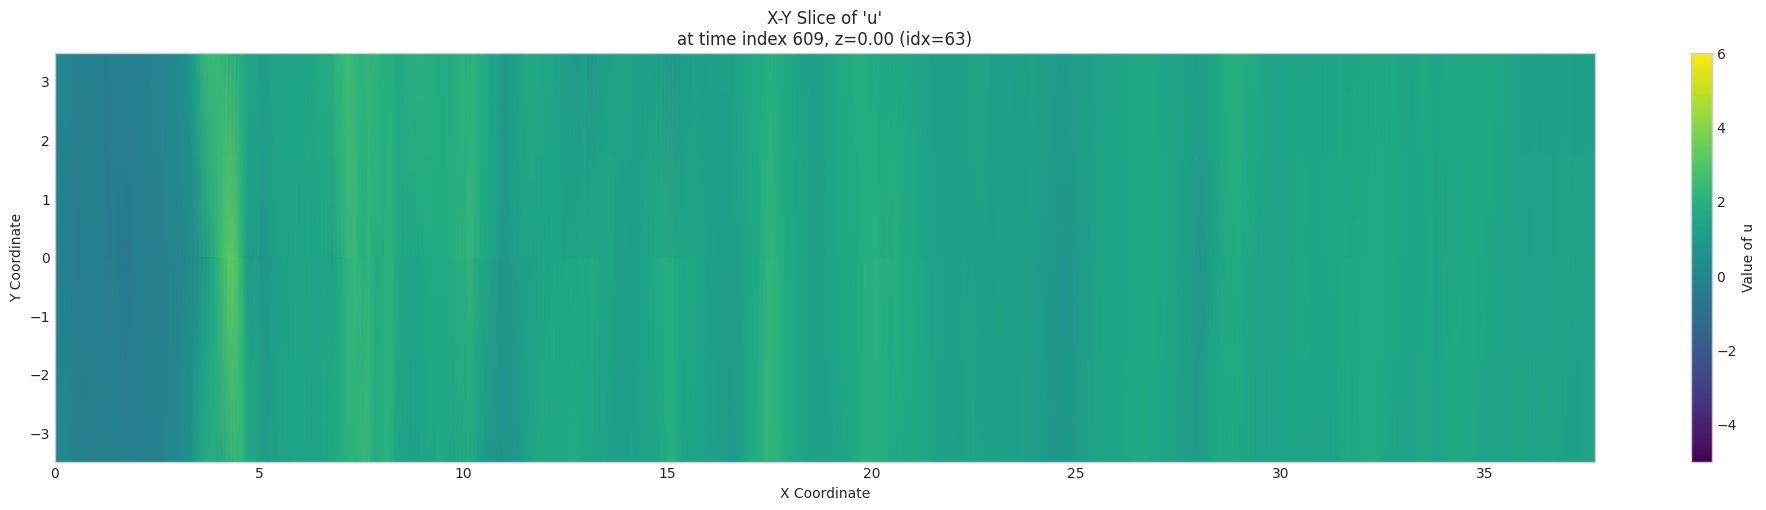

In [10]:
# === Plot X-Y Slice for u (vx) ===
if 'vx' in velocity_components:
    plot_xy_slice(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vx',
        z_index=plot_z_index_xy,
        time_index=plot_time_index_xy,
        channel_alias=channel_map.get('vx'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

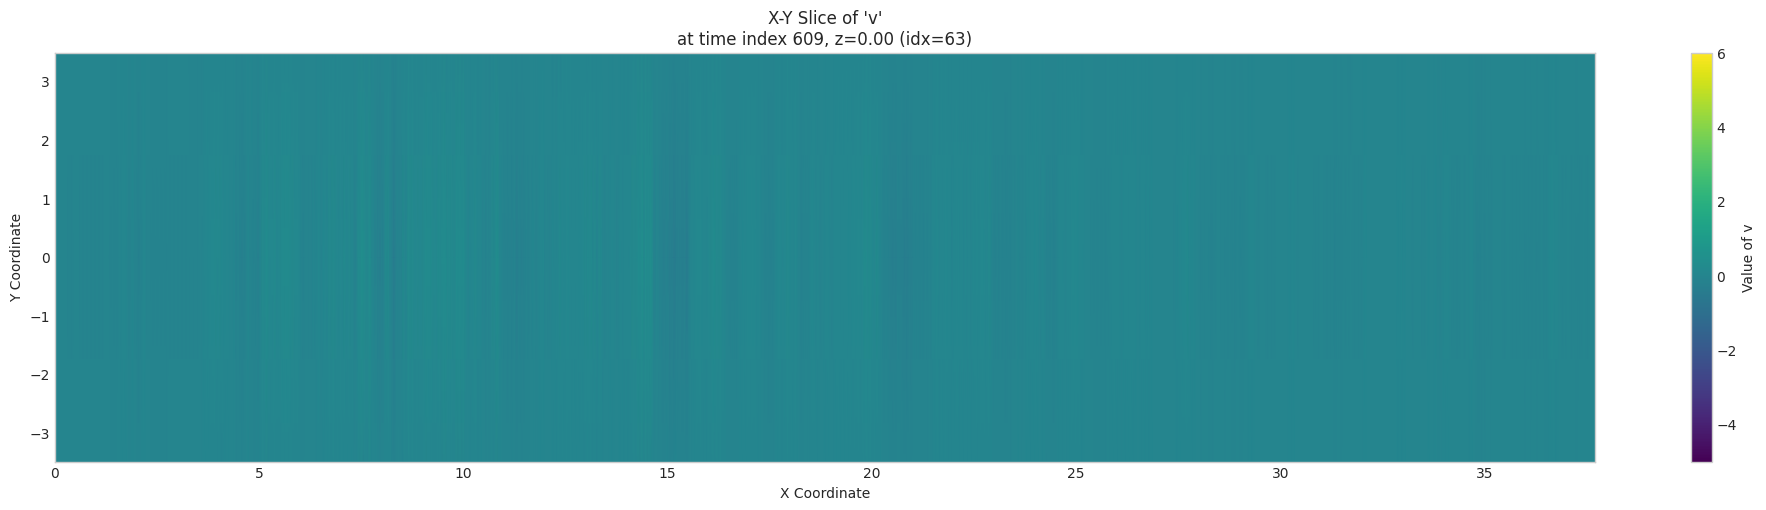

In [11]:
# === Plot X-Y Slice for v (vy) ===
if 'vy' in velocity_components:
    plot_xy_slice(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vy',
        z_index=plot_z_index_xy,
        time_index=plot_time_index_xy,
        channel_alias=channel_map.get('vy'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

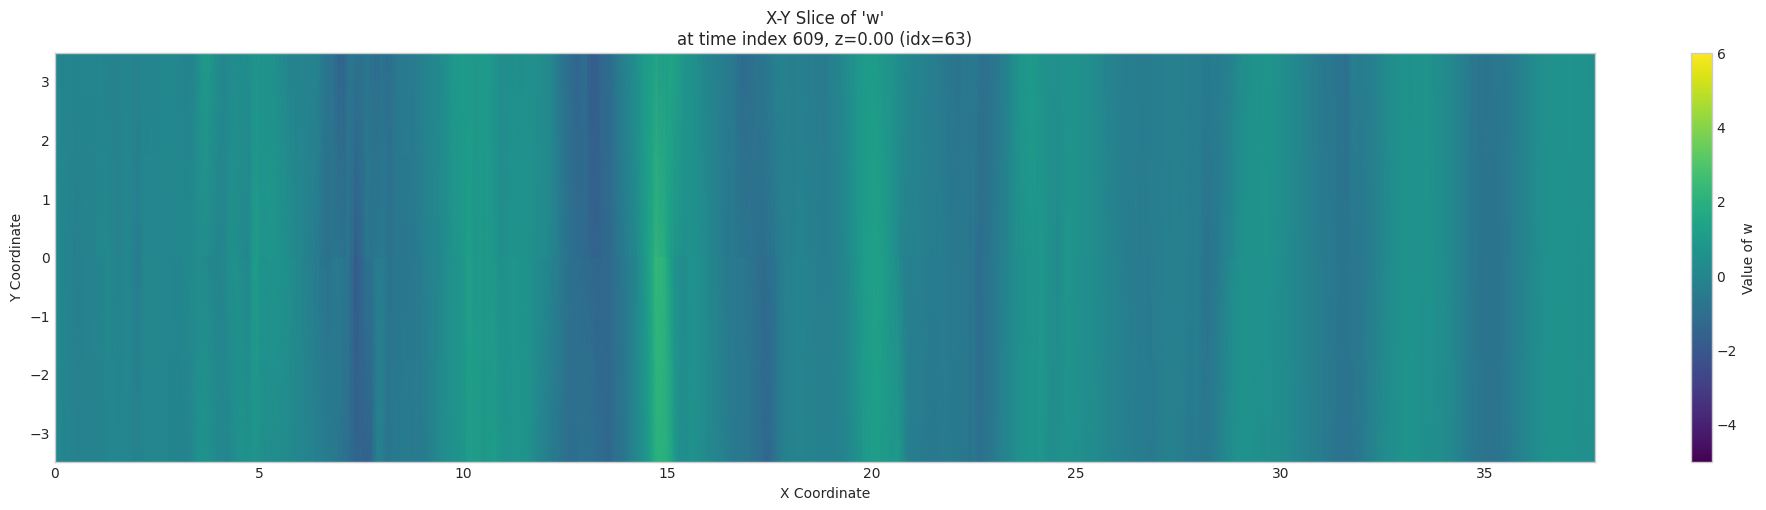

In [12]:
# === Plot X-Y Slice for w (vz) ===
if 'vz' in velocity_components:
    plot_xy_slice(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vz',
        z_index=plot_z_index_xy,
        time_index=plot_time_index_xy,
        channel_alias=channel_map.get('vz'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

#### 5.3 Y-Z Slices (at constant X)

In [13]:
# === Parameters for Y-Z Slices ===
# <<< MODIFY THESE VALUES >>>
plot_x_index_yz = max_x_index // 2
plot_time_index_yz = max_time_index // 2
# ---
print(f"Using x-index {plot_x_index_yz} and time-index {plot_time_index_yz} for Y-Z slice plots.")

Using x-index 575 and time-index 609 for Y-Z slice plots.


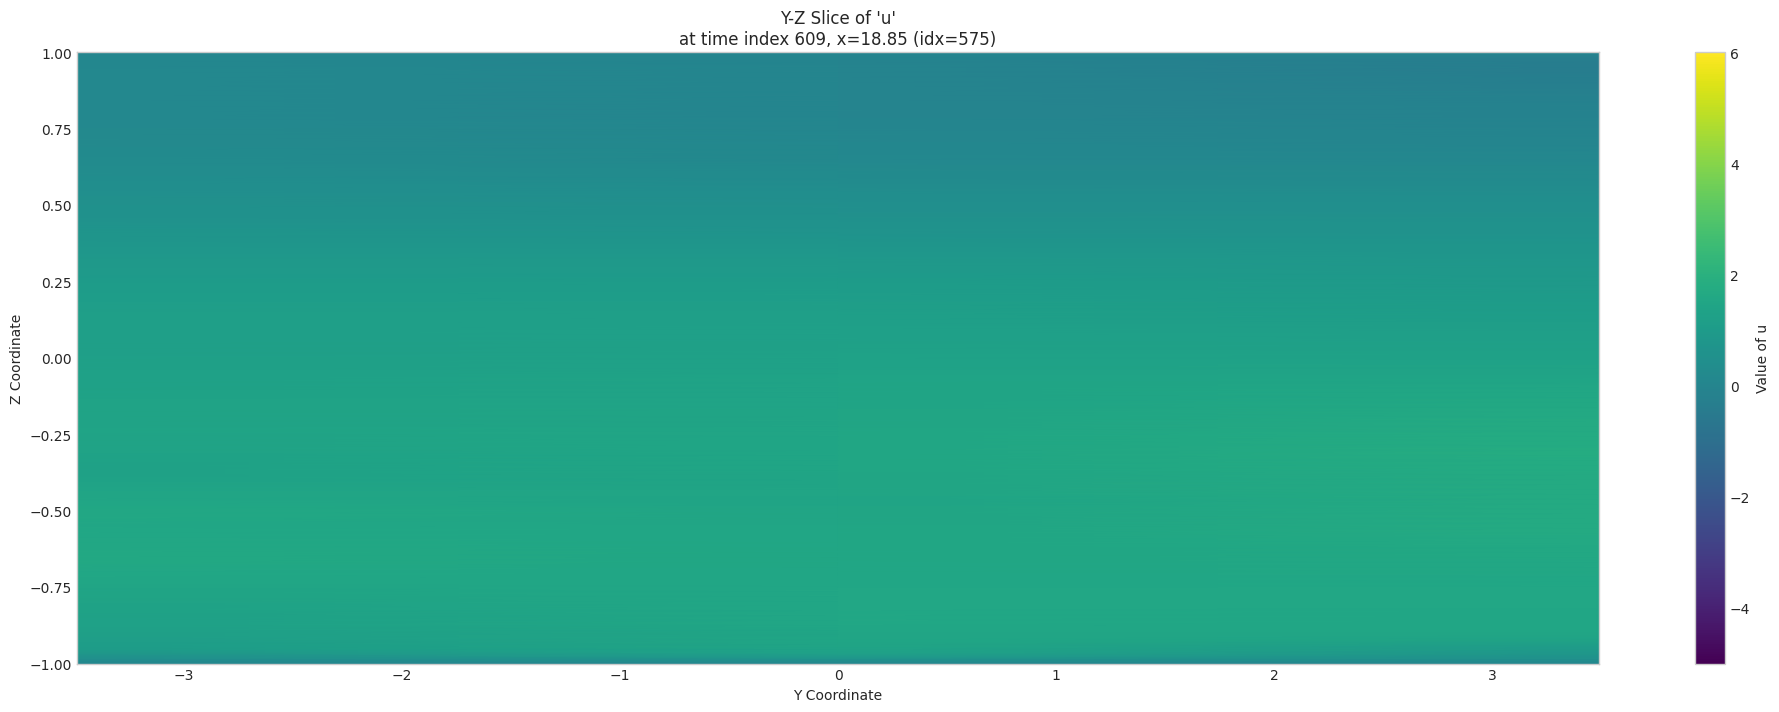

In [14]:
# === Plot Y-Z Slice for u (vx) ===
if 'vx' in velocity_components:
    plot_yz_slice(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vx',
        x_index=plot_x_index_yz,
        time_index=plot_time_index_yz,
        channel_alias=channel_map.get('vx'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

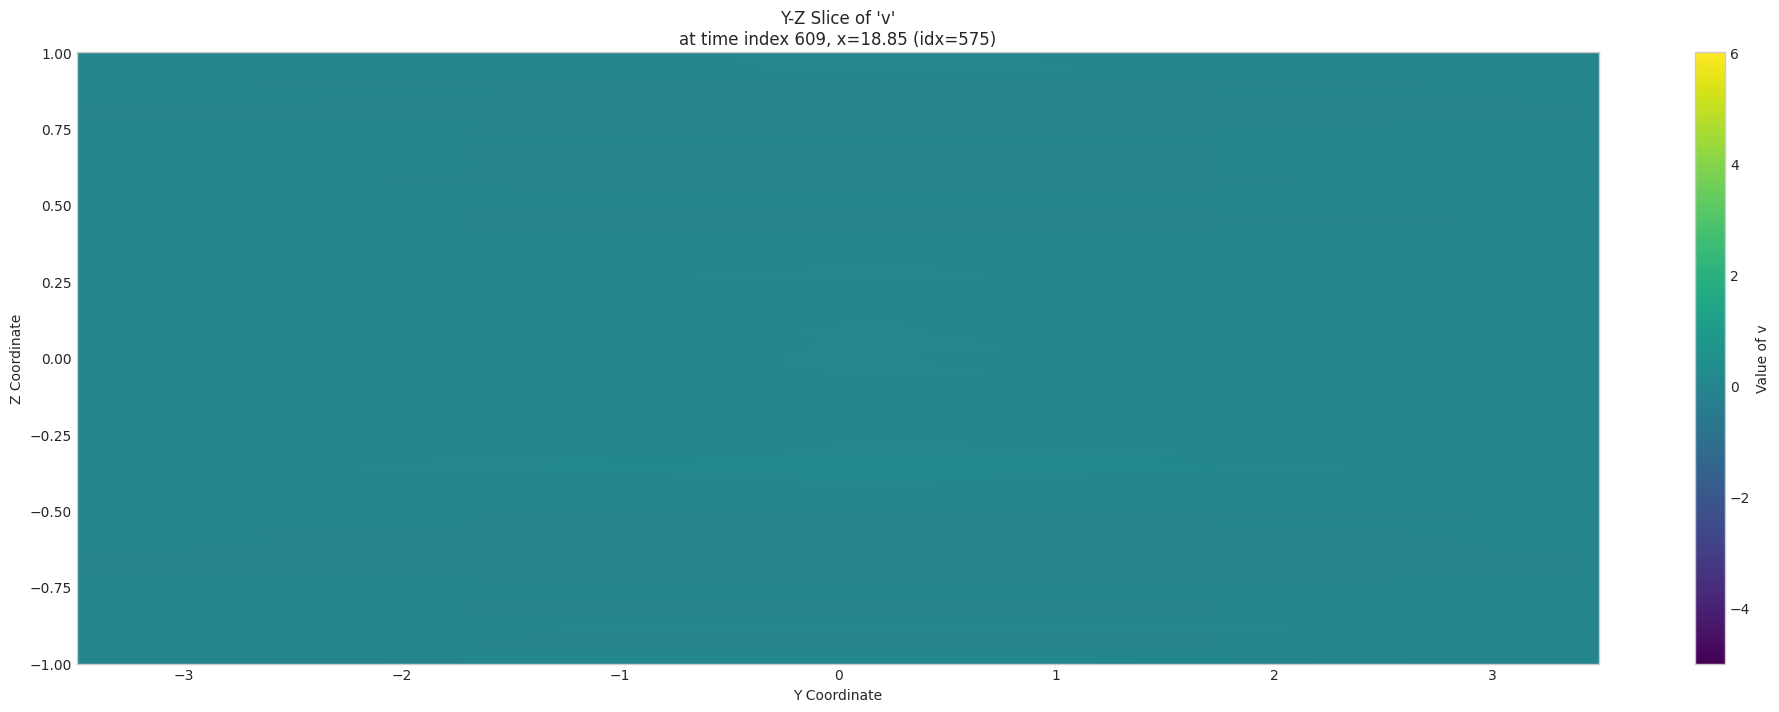

In [15]:
# === Plot Y-Z Slice for v (vy) ===
if 'vy' in velocity_components:
    plot_yz_slice(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vy',
        x_index=plot_x_index_yz,
        time_index=plot_time_index_yz,
        channel_alias=channel_map.get('vy'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

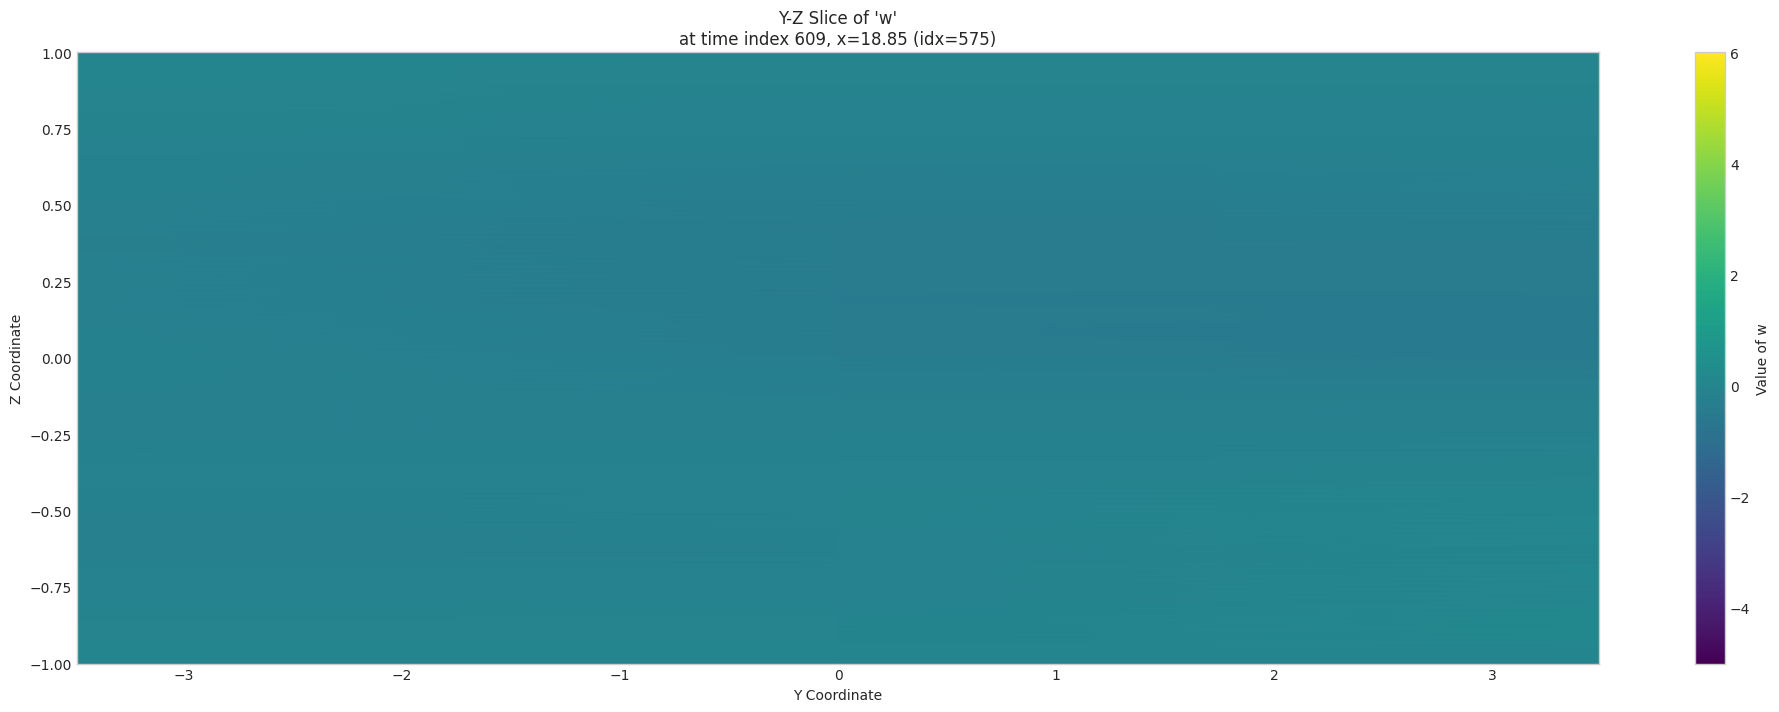

In [16]:
# === Plot Y-Z Slice for w (vz) ===
if 'vz' in velocity_components:
    plot_yz_slice(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vz',
        x_index=plot_x_index_yz,
        time_index=plot_time_index_yz,
        channel_alias=channel_map.get('vz'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

---

### 6. Time Evolution Plots (1D Line over Time)

#### 6.1 Evolution along Z-axis (at constant X, Y)

In [17]:
# === Parameters for Time-Z Plots ===
# <<< MODIFY THESE VALUES >>>
plot_x_index_tz = max_x_index // 2
plot_y_index_tz = max_y_index // 2
# ---
print(f"Using x-index {plot_x_index_tz} and y-index {plot_y_index_tz} for Time-Z plots.")

Using x-index 575 and y-index 2 for Time-Z plots.


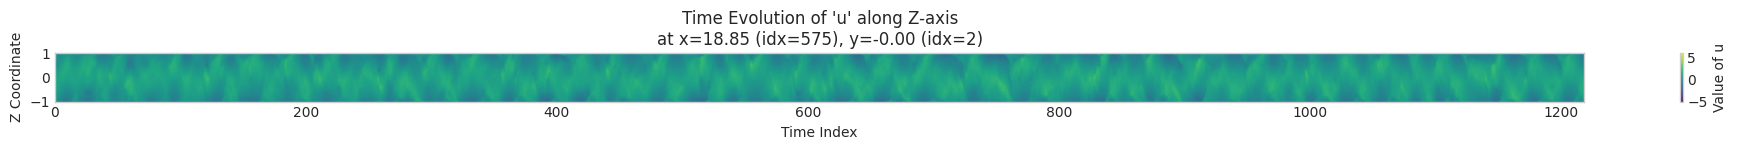

In [18]:
# === Plot Time-Z Evolution for u (vx) ===
if 'vx' in velocity_components:
    plot_z_time_evolution(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vx',
        x_index=plot_x_index_tz,
        y_index=plot_y_index_tz,
        channel_alias=channel_map.get('vx'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

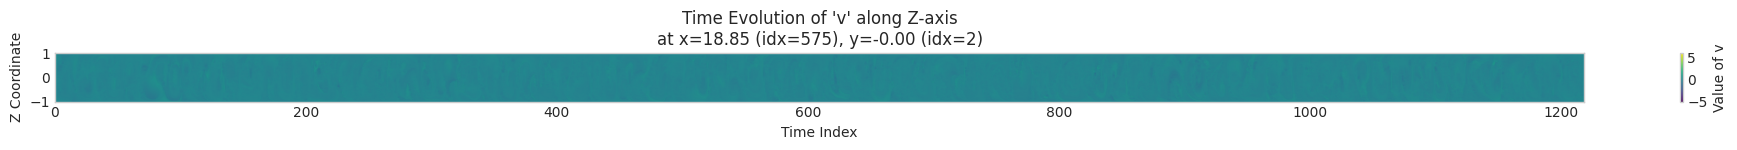

In [19]:
# === Plot Time-Z Evolution for v (vy) ===
if 'vy' in velocity_components:
    plot_z_time_evolution(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vy',
        x_index=plot_x_index_tz,
        y_index=plot_y_index_tz,
        channel_alias=channel_map.get('vy'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

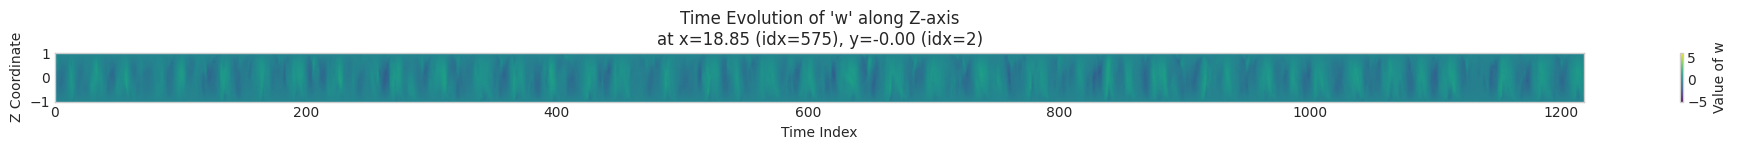

In [20]:
# === Plot Time-Z Evolution for w (vz) ===
if 'vz' in velocity_components:
    plot_z_time_evolution(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vz',
        x_index=plot_x_index_tz,
        y_index=plot_y_index_tz,
        channel_alias=channel_map.get('vz'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

#### 6.2 Evolution along X-axis (at constant Y, Z)

In [21]:
# === Parameters for Time-X Plots ===
# <<< MODIFY THESE VALUES >>>
plot_y_index_tx = max_y_index // 2
plot_z_index_tx = max_z_index // 2
# ---
print(f"Using y-index {plot_y_index_tx} and z-index {plot_z_index_tx} for Time-X plots.")

Using y-index 2 and z-index 63 for Time-X plots.


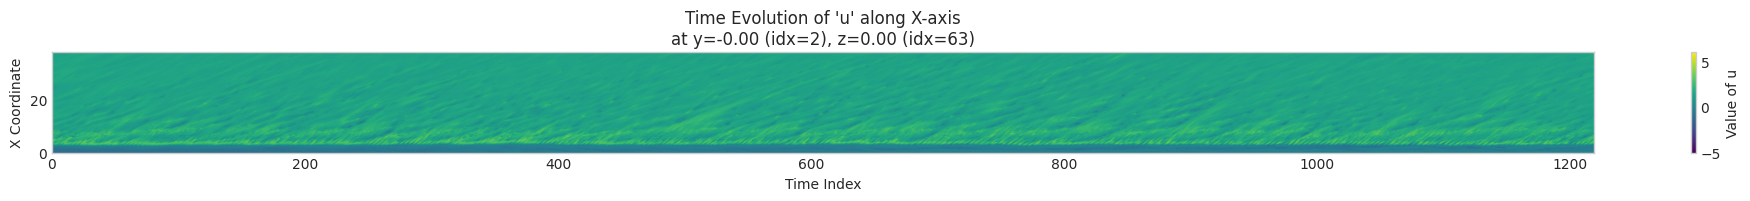

In [22]:
# === Plot Time-X Evolution for u (vx) ===
if 'vx' in velocity_components:
    plot_x_time_evolution(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vx',
        y_index=plot_y_index_tx,
        z_index=plot_z_index_tx,
        channel_alias=channel_map.get('vx'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

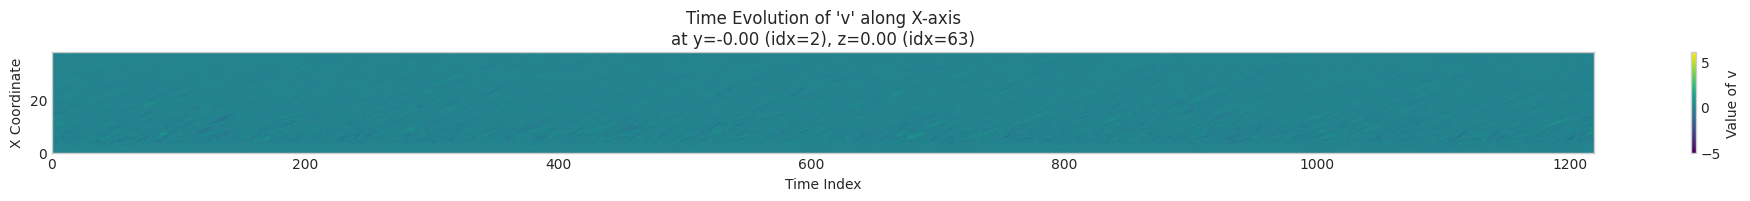

In [23]:
# === Plot Time-X Evolution for v (vy) ===
if 'vy' in velocity_components:
    plot_x_time_evolution(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vy',
        y_index=plot_y_index_tx,
        z_index=plot_z_index_tx,
        channel_alias=channel_map.get('vy'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

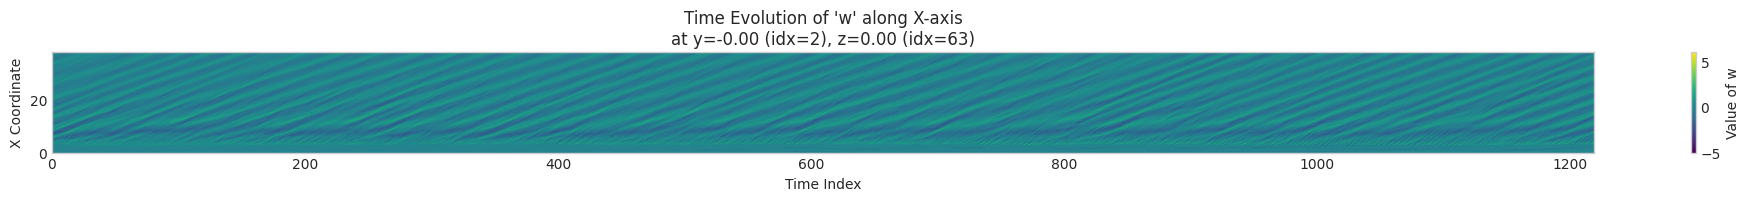

In [24]:
# === Plot Time-X Evolution for w (vz) ===
if 'vz' in velocity_components:
    plot_x_time_evolution(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vz',
        y_index=plot_y_index_tx,
        z_index=plot_z_index_tx,
        channel_alias=channel_map.get('vz'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

#### 6.3 Evolution along Y-axis (at constant X, Z)

In [25]:
# === Parameters for Time-Y Plots ===
# <<< MODIFY THESE VALUES >>>
plot_x_index_ty = max_x_index // 2
plot_z_index_ty = max_z_index // 2
# ---
print(f"Using x-index {plot_x_index_ty} and z-index {plot_z_index_ty} for Time-Y plots.")

Using x-index 575 and z-index 63 for Time-Y plots.


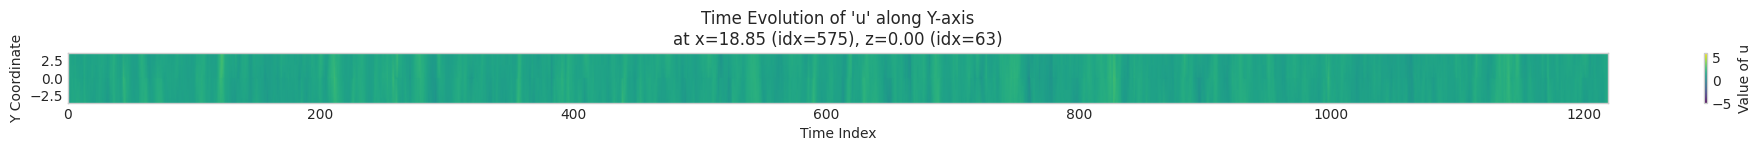

In [26]:
# === Plot Time-Y Evolution for u (vx) ===
if 'vx' in velocity_components:
    plot_y_time_evolution(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vx',
        x_index=plot_x_index_ty,
        z_index=plot_z_index_ty,
        channel_alias=channel_map.get('vx'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

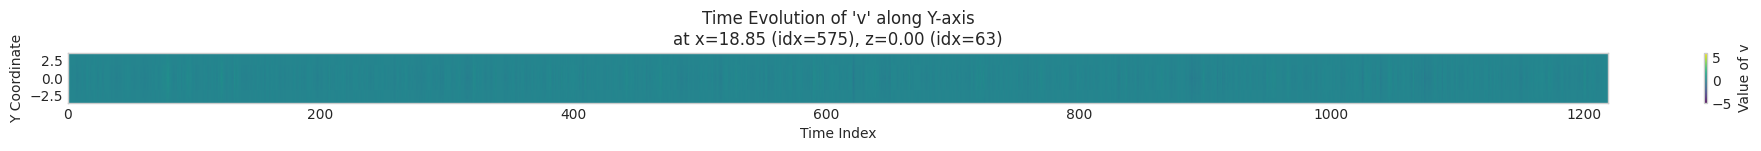

In [27]:
# === Plot Time-Y Evolution for v (vy) ===
if 'vy' in velocity_components:
    plot_y_time_evolution(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vy',
        x_index=plot_x_index_ty,
        z_index=plot_z_index_ty,
        channel_alias=channel_map.get('vy'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )

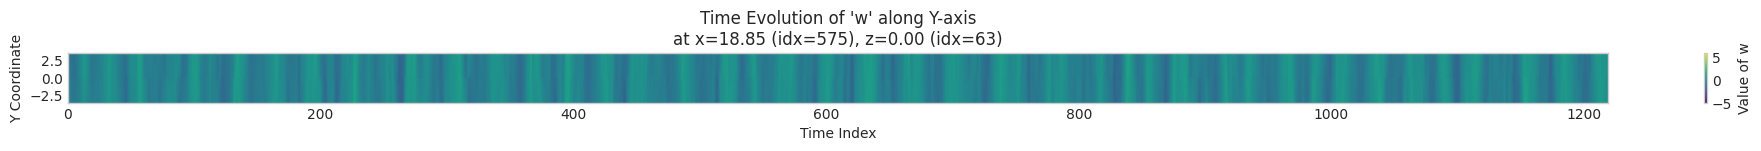

In [28]:
# === Plot Time-Y Evolution for w (vz) ===
if 'vz' in velocity_components:
    plot_y_time_evolution(
        data_path=None,
        timeseries_data=timeseries_data,
        coords=coords,
        channel='vz',
        x_index=plot_x_index_ty,
        z_index=plot_z_index_ty,
        channel_alias=channel_map.get('vz'),
        vmin=global_timeseries_vmin,
        vmax=global_timeseries_vmax,
        base_size=global_base_size,
        min_size=global_min_size,
        unit_label=global_unit_label
    )